# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [131]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np

from zavolab_pyutils.read_count_simulation import simulate_negative_binomial_counts, simulate_poisson_lognormal_counts
from zavolab_pyutils.read_count_data_analysis import apply_deseq2_normalization, model_mean_variance, apply_sanity_normalization
from zavolab_pyutils.visualization import plot_size_factors, plot_mean_variance_diagnostics, plot_gene_expression_with_ci, plot_mean_vs_cv, plot_expr_vs_libsize_correlation, plot_sanity_gene_expression_with_ci, plot_variance_vs_expression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [132]:
?apply_deseq2_normalization

Signature:
apply_deseq2_normalization(
    counts_df,
    metadata_df,
    sample_col='sample',
    cond_col='condition',
    lowExprGenesQ=0.3,
    pseudocount=1,
)
Docstring:
Performs DESeq2-style median-of-ratios normalization.

Parameters
----------
counts_df : pd.DataFrame
    Raw count matrix (genes x samples). May contain any additional columns.
metadata_df : pd.DataFrame
    Metadata mapping samples to biological conditions.
sample_col : str, optional
    Column name in metadata_df containing sample IDs. Default is 'sample'.
cond_col : str, optional
    Column name in metadata_df containing condition labels. Default is 'condition'.
    (Provided for API consistency, though size factors are computed globally).
lowExprGenesQ: float, optional
    The quantile specifying the threshold to discard low-expressed genes 
    for size factor calculation. Default is 0.3.
pseudocount: float, optional
    Added count before dividing by size factor value. Essential if further 
    log2 trans

## Create sample count data

In [81]:
# we generate the data under assumption of NO differentially expressed genes, so any significant changes between conditions are false positives!

In [129]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_df, metadata_df, true_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    alpha=0.05, # The true variance target
    seed=100,
    SF_sigma=0.1,
)

print("Negative Binomial Counts:")
print(nb_counts_df.head())

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1         0         0         0         0         0         0
Gene_2        37        55        44        61        73        41
Gene_3       438       578       481       769       592       518
Gene_4        10         4         6         9         4        12
Gene_5       376       623       250       322       419       347


In [130]:
# Generate Sanity-style data (Poisson-LogNormal)
pln_counts_df, metadata_df, true_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    v_log=0.05, # The true variance target
    seed=100,
    SF_sigma=0.1,
)

print("\nPoisson-LogNormal Counts:")
print(pln_counts_df.head())


Poisson-LogNormal Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1         0         0         0         0         0         0
Gene_2        37        72        86        45        59        57
Gene_3       520       753       787       636      1040       525
Gene_4         6        12        11        16         6         6
Gene_5       401       358       231       300       600       380


## DESeq2-style normalization and quantification

In [125]:
# Apply normalization
norm_counts_df, sfs_df = apply_deseq2_normalization(
    pln_counts_df, 
    metadata_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts_df)
print(f"\nShape: {norm_counts_df.shape}")

Normalized count matrix:
             Sample_1    Sample_2    Sample_3    Sample_4    Sample_5  \
Gene_1       1.760315    0.936896    0.726120    1.127163    0.782800   
Gene_2      47.528496   73.077860   79.147061   49.595153   57.144403   
Gene_3     638.994227  757.011673  720.310863  681.933351  987.110848   
Gene_4      10.561888    8.432061    8.713438   13.525951    8.610800   
Gene_5     438.318354  453.457487  389.926344  322.368493  282.590814   
...               ...         ...         ...         ...         ...   
Gene_2996    1.760315    2.810687    5.082839    2.254325    3.131200   
Gene_2997   17.603147   11.242748   29.044793   15.780276   24.266801   
Gene_2998    1.760315    0.936896    0.726120    3.381488    1.565600   
Gene_2999   14.082517   19.674808   22.509714   30.433389   19.570001   
Gene_3000    5.280944    6.558269    5.808959    5.635813    5.479600   

             Sample_6  
Gene_1       0.897100  
Gene_2      57.414397  
Gene_3     523.009272  
Ge

### Size factors and QC metrics

In [126]:
print("Size factors and read metrics:")
print(sfs_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf  read_sum  read_sum_mln
sample                                              
Sample_1  0.568080 -0.815833   4957298          4.96
Sample_2  1.067355  0.094040  11088671         11.09
Sample_3  1.377183  0.461720  13999845         14.00
Sample_4  0.887183 -0.172696   8426610          8.43
Sample_5  1.277465  0.353284  11245587         11.25
Sample_6  1.114703  0.156659  10074488         10.07


### Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [6]:
print(f"Median size factor: {sfs_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_df['sf'].mean():.3f}")
print("\n✓ Normalization completed successfully!")

Median size factor: 1.013
Mean size factor: 1.010

✓ Normalization completed successfully!


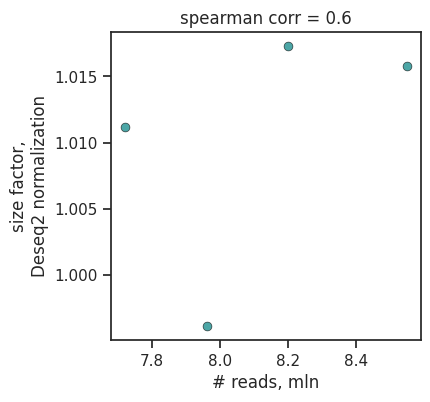

In [7]:
plot_size_factors(sfs_df,outdir='./tests/plots/')

### Mean-Variance Modeling and Confidence Intervals

In [8]:
# Model the condition-specific dispersion using Quantile Regression
regr_model_df, all_plot_data = model_mean_variance(
    norm_counts_df, 
    metadata_df, 
    sample_col='sample', 
    cond_col='condition'
)

print("\nRegression Model Parameters (Alpha/Dispersion):")
print(regr_model_df)


Regression Model Parameters (Alpha/Dispersion):
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.029418
1  Treatment   QuantReg          var  0.022920


In [ ]:
# WARNING: param values should be very similar to the specified value of alpha (see above)!
# CURRENT status: it does not match

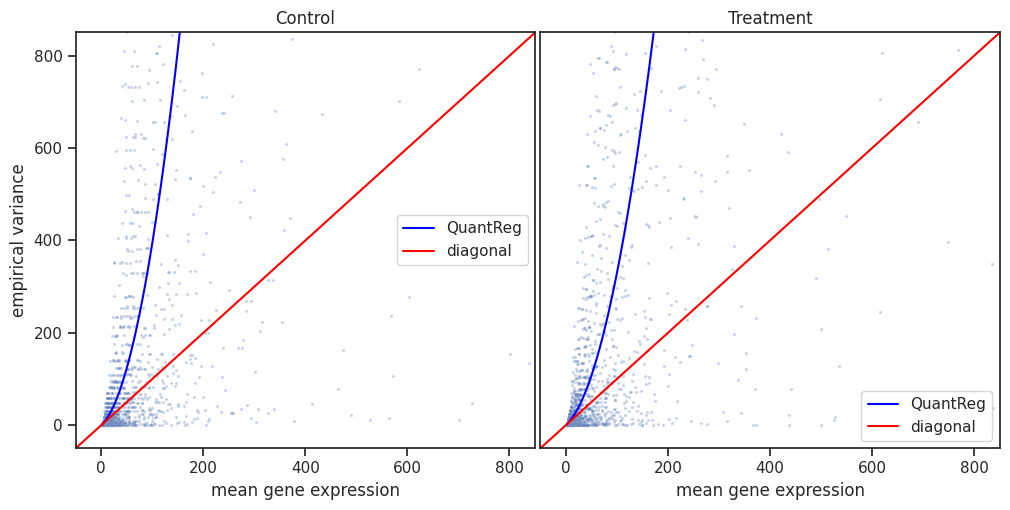

In [9]:
# Plot the diagnostic regression fits for variance within each condition
plot_mean_variance_diagnostics(
    all_plot_data, 
    savefig_path='./tests/plots/mean_variance_diagnostics.png'
)

## Sanity style normalization and quantification

In [114]:
# first, run Sanity without Empirical Bayes Shrinkage (as in the original paper)
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=pln_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=False,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2856 genes using 5 cores...
PASS 3: Finalizing Bayesian Posteriors...
Sanity normalization complete.


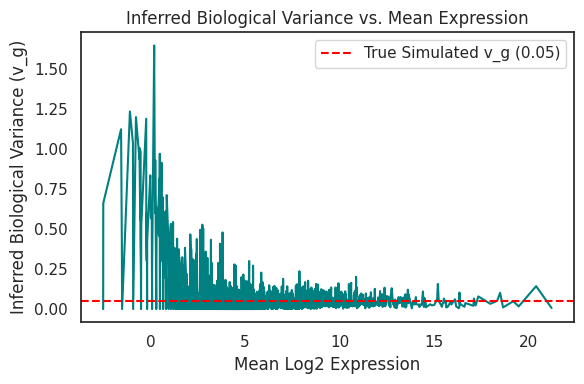

In [116]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.without_Empir_Bayes_Shrinkage.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

In [117]:
# now, run Sanity with Empirical Bayes Shrinkage that takes advantage of mean-variance relatioship across genes
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=pln_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=True,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2856 genes using 5 cores...
PASS 2: Applying Empirical Bayes Variance Shrinkage...
PASS 3: Finalizing Bayesian Posteriors...
Sanity normalization complete.


In [119]:
sanity_vg_df.head()

,inferred_v_g,raw_v_g
Gene_2,0.043288,0.003440
Gene_3,0.056396,0.039561
Gene_4,0.017377,0.000100
Gene_5,0.061618,0.084047
Gene_6,0.056800,0.133165


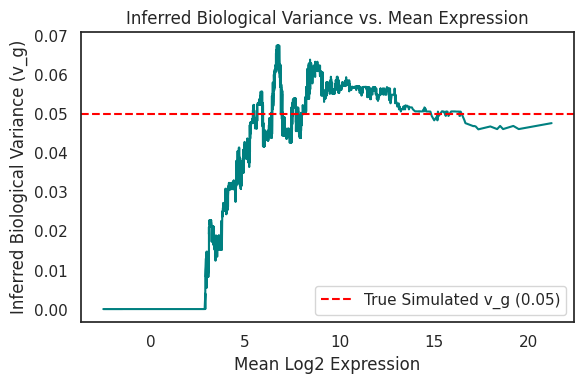

In [118]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

## Diagnostic plots for expression normalization confounders

these make more sense at larger number of replicates, like >15, because otherwise observed between-bioreplicate variance is mostly just technical noise

KeyError: "['Sample_5', 'Sample_6'] not in index"

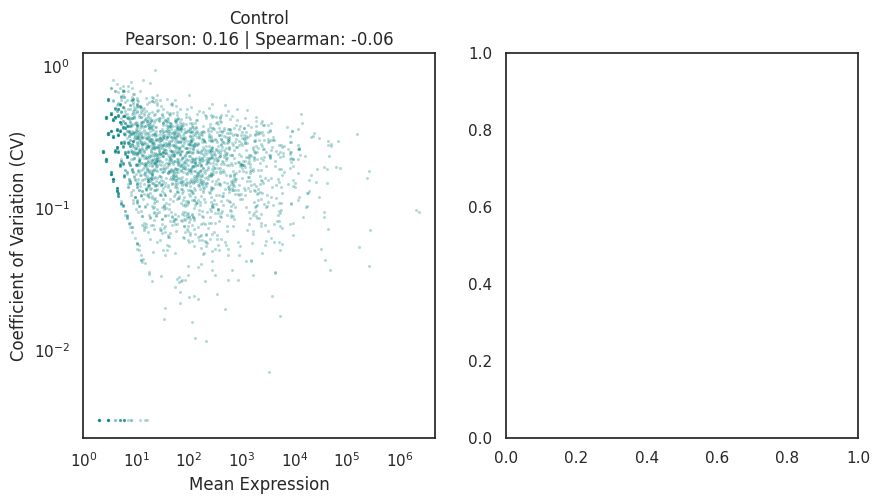

In [120]:
# 1. DESeq2 Mean vs CV (is_log2 = False because norm_counts is on raw scale)
plot_mean_vs_cv(
    norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_deseq2.png', 
    is_log2=False
)
# 2. Sanity Mean vs CV (is_log2 = True to convert log2 back to raw for CV math)
plot_mean_vs_cv(
    sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_sanity.png', 
    is_log2=True
)
# Sanity is highly effective at shrinking the variance of low-expression genes, 
# flattening the left side of the curve!

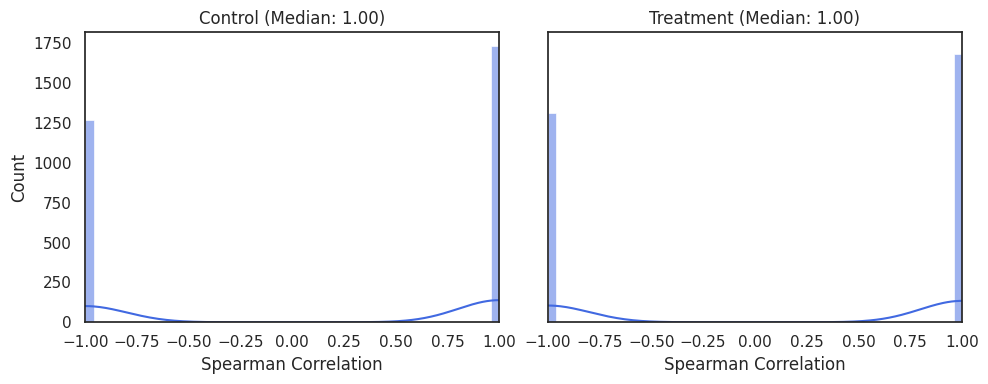

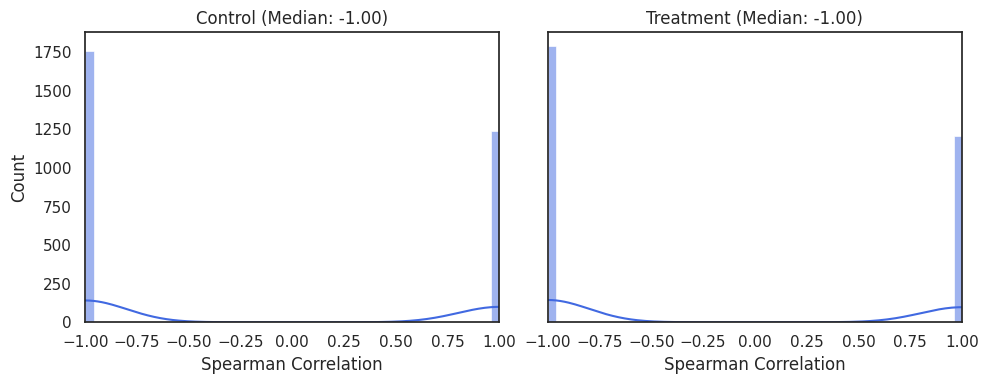

In [51]:
# 1. DESeq2 library size correction checks
plot_expr_vs_libsize_correlation(
    counts_df, norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/libsize_corr_deseq2.png',
    method='spearman', separate_conditions=True
)
# 2. Sanity library size correction checks
plot_expr_vs_libsize_correlation(
    counts_df, sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/libsize_corr_sanity.png',
    method='spearman', separate_conditions=True
)

## Plottting expression of individual genes with confidence intervals

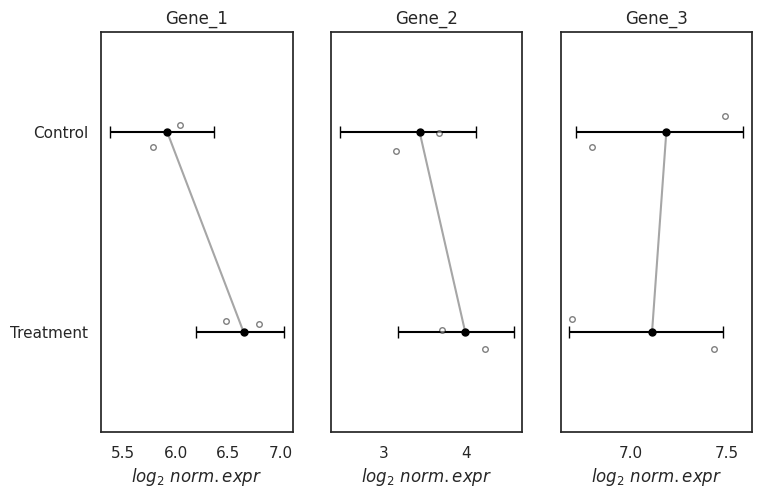

In [54]:
# Select specific genes of interest to visualize their differential expression
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

# Plot log2 expression with exact Negative Binomial confidence intervals
plot_gene_expression_with_ci(
    norm_counts_df, 
    metadata_df, 
    selected_genes, 
    regr_model_df, 
    savefig_path='./tests/plots/deseq_expression_ci.png',
    sample_col='sample', 
    cond_col='condition'
)

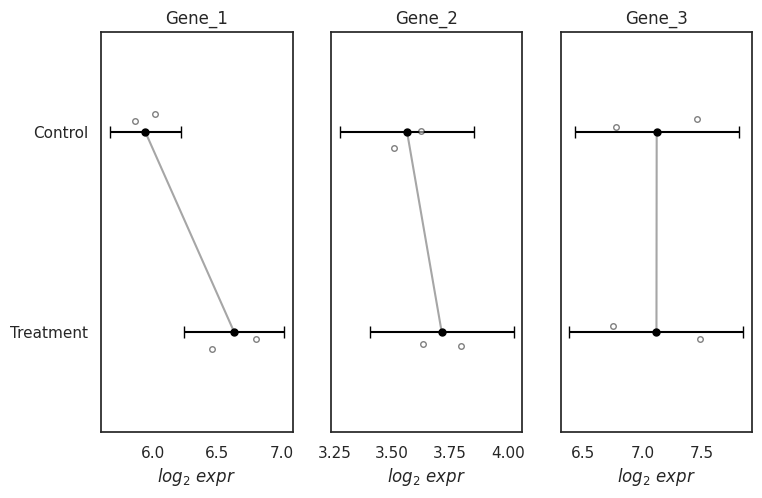

In [52]:
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

plot_sanity_gene_expression_with_ci(
    sample_norm_df=sanity_norm_counts_df, 
    means_df=sanity_means_df, 
    errors_df=sanity_errors_df, 
    metadata_df=metadata_df, 
    selected_genes=selected_genes, 
    savefig_path='./tests/plots/sanity_expression_ci.png'
)

In [38]:
sanity_errors_df.head()

,Control,Treatment
Gene_1,0.140556,0.197406
Gene_2,0.148464,0.158664
Gene_3,0.353321,0.374556
Gene_4,0.123279,0.066133
Gene_5,0.192453,0.270254


In [36]:
sanity_norm_counts_df.head()

,Sample_1,Sample_2,Sample_3,Sample_4
Gene_1,5.862259,6.018788,6.802866,6.460013
Gene_2,3.622277,3.505540,3.795402,3.631737
Gene_3,7.461125,6.773632,7.480359,6.750491
Gene_4,10.890683,10.648692,11.023000,11.147782
Gene_5,3.852564,3.647221,3.580714,4.010850
